In [3]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import sqrtm
from tensorflow.keras.datasets import mnist
from tensorflow.keras.applications.inception_v3 import InceptionV3
from tensorflow.keras.applications.inception_v3 import preprocess_input

# Load and preprocess dataset
(x_train, _), (_, _) = mnist.load_data()
x_train = (x_train.astype('float32') - 127.5) / 127.5  # Normalize to [-1, 1]
x_train = np.expand_dims(x_train, axis=-1)  # Expand dimensions to (28,28,1)

# Constants
BUFFER_SIZE = 60000
BATCH_SIZE = 256
LATENT_DIM = 100
EPOCHS = 50

# Prepare dataset
dataset = tf.data.Dataset.from_tensor_slices(x_train).shuffle(BUFFER_SIZE).batch(BATCH_SIZE)

# Generator Model
def build_generator():
    model = keras.Sequential([
        layers.Dense(7 * 7 * 256, use_bias=False, input_shape=(LATENT_DIM,)),
        layers.BatchNormalization(),
        layers.LeakyReLU(),
        layers.Reshape((7, 7, 256)),
        layers.Conv2DTranspose(128, (5, 5), strides=(1, 1), padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(),
        layers.Conv2DTranspose(64, (5, 5), strides=(2, 2), padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(),
        layers.Conv2DTranspose(1, (5, 5), strides=(2, 2), padding='same', use_bias=False, activation='tanh')
    ])
    return model

# Discriminator Model
def build_discriminator():
    model = keras.Sequential([
        layers.Conv2D(64, (5, 5), strides=(2, 2), padding='same', input_shape=[28, 28, 1]),
        layers.LeakyReLU(),
        layers.Dropout(0.3),
        layers.Conv2D(128, (5, 5), strides=(2, 2), padding='same'),
        layers.LeakyReLU(),
        layers.Dropout(0.3),
        layers.Flatten(),
        layers.Dense(1)
    ])
    return model

# Loss functions and optimizers
def generator_loss(fake_output):
    return tf.keras.losses.BinaryCrossentropy(from_logits=True)(tf.ones_like(fake_output), fake_output)

def discriminator_loss(real_output, fake_output):
    real_loss = tf.keras.losses.BinaryCrossentropy(from_logits=True)(tf.ones_like(real_output), real_output)
    fake_loss = tf.keras.losses.BinaryCrossentropy(from_logits=True)(tf.zeros_like(fake_output), fake_output)
    return real_loss + fake_loss

generator = build_generator()
discriminator = build_discriminator()

gen_optimizer = tf.keras.optimizers.Adam(1e-4)
disc_optimizer = tf.keras.optimizers.Adam(1e-4)

# Training step
@tf.function
def train_step(images):
    noise = tf.random.normal([BATCH_SIZE, LATENT_DIM])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        generated_images = generator(noise, training=True)
        real_output = discriminator(images, training=True)
        fake_output = discriminator(generated_images, training=True)
        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)

    gradients_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    gen_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))
    disc_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))

# Training loop
def train(dataset, epochs):
    for epoch in range(epochs):
        for image_batch in dataset:
            train_step(image_batch)
        print(f"Epoch {epoch + 1} completed")

# Compute FID
def calculate_fid(real_images, fake_images):
    inception = InceptionV3(include_top=False, pooling='avg', input_shape=(75, 75, 3))

    real_images = np.repeat(real_images, 3, axis=-1)  # Convert grayscale to RGB
    real_images = tf.image.resize(real_images, (75, 75)).numpy()
    fake_images = np.repeat(fake_images, 3, axis=-1)
    fake_images = tf.image.resize(fake_images, (75, 75)).numpy()

    act1 = inception.predict(preprocess_input(real_images))
    act2 = inception.predict(preprocess_input(fake_images))

    mu1, sigma1 = act1.mean(axis=0), np.cov(act1, rowvar=False)
    mu2, sigma2 = act2.mean(axis=0), np.cov(act2, rowvar=False)

    ssdiff = np.sum((mu1 - mu2)**2.0)
    covmean = sqrtm(sigma1.dot(sigma2))

    if np.iscomplexobj(covmean):
        covmean = covmean.real

    fid = ssdiff + np.trace(sigma1 + sigma2 - 2.0 * covmean)
    return fid

# Generate images
def generate_images():
    noise = tf.random.normal([BATCH_SIZE, LATENT_DIM])
    return generator(noise, training=False).numpy()

# Train the GAN
train(dataset, EPOCHS)

# Compute FID score
real_samples = x_train[np.random.choice(len(x_train), BATCH_SIZE, replace=False)]
fake_samples = generate_images()
print("FID Score:", calculate_fid(real_samples, fake_samples))



11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1 completed
Epoch 2 completed
Epoch 3 completed
Epoch 4 completed
Epoch 5 completed
Epoch 6 completed
Epoch 7 completed
Epoch 8 completed
Epoch 9 completed
Epoch 10 completed
Epoch 11 completed
Epoch 12 completed
Epoch 13 completed
Epoch 14 completed
Epoch 15 completed
Epoch 16 completed
Epoch 17 completed
Epoch 18 completed
Epoch 19 completed
Epoch 20 completed
Epoch 21 completed
Epoch 22 completed
Epoch 23 completed
Epoch 24 completed
Epoch 25 completed
Epoch 26 completed
Epoch 27 completed
Epoch 28 completed
Epoch 29 completed
Epoch 30 completed
Epoch 31 completed
Epoch 32 completed
Epoch 33 completed
Epoch 34 completed
Epoch 35 completed
Epoch 36 completed
Epoch 37 completed
Epoch 38 completed
Epoch 39 completed
Epoch 40 completed
Epoch 41 completed
Epoch 42 completed
Epoch 43 completed
Epoch 44 completed
Epoch 45 completed
Epoch 46 completed
Epoch 47 completed
Epoch 48 completed
Epoch 49 completed
Epoch 50 completed
87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
8/8 ━━━━

/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Episode 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/backend/tensorflow/trainer.py:82: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


Episode 1 Total reward: -7.888585925102234
Episode 2/10
Episode 2 Total reward: -7.774434685707092
Episode 3/10
Episode 3 Total reward: -7.737750887870789
Episode 4/10
Episode 4 Total reward: -7.715545117855072
Episode 5/10
Episode 5 Total reward: -7.72593766450882
Episode 6/10
Episode 6 Total reward: -7.720362603664398
Episode 7/10
Episode 7 Total reward: -7.717380166053772
Episode 8/10
Episode 8 Total reward: -7.729191362857819
Episode 9/10
Episode 9 Total reward: -7.722758054733276
Episode 10/10
Episode 10 Total reward: -7.720452666282654


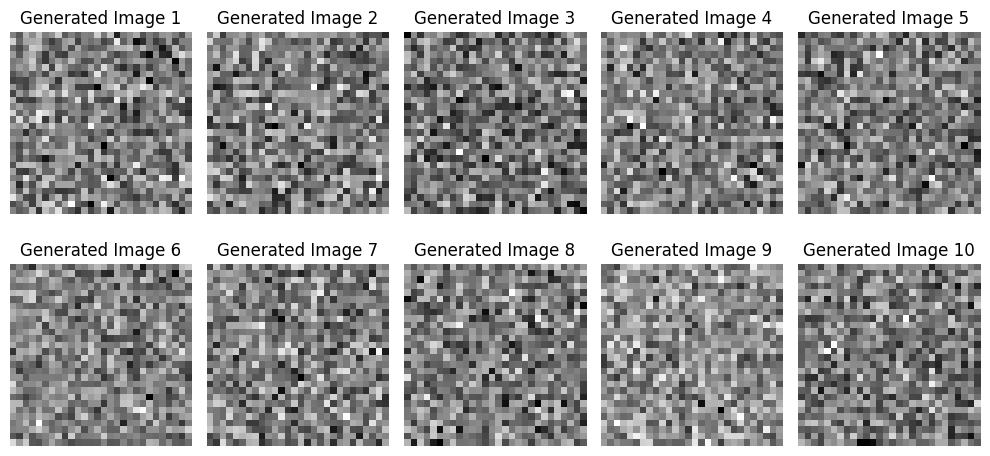

In [4]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from collections import deque
import random
import matplotlib.pyplot as plt

# Hyperparameters
gamma = 0.99  # Discount factor
epsilon = 1.0  # Exploration rate
epsilon_min = 0.1
epsilon_decay = 0.995
learning_rate = 0.001
batch_size = 32
num_episodes = 10  # Number of episodes
max_steps = 10  # Max steps per episode
memory = deque(maxlen=2000)  # Experience replay memory

# Load and preprocess MNIST dataset
(X_train, _), (_, _) = keras.datasets.mnist.load_data()
X_train = X_train.reshape(-1, 28, 28, 1).astype('float32') / 255.0  # Normalize

# GAN components (Generator and Discriminator)
def build_generator(latent_dim):
    model = keras.Sequential([
        keras.layers.Dense(128, activation='relu', input_dim=latent_dim),
        keras.layers.Dense(28 * 28 * 1, activation='sigmoid'),
        keras.layers.Reshape((28, 28, 1))
    ])
    return model

def build_discriminator():
    model = keras.Sequential([
        keras.layers.Flatten(input_shape=(28, 28, 1)),
        keras.layers.Dense(128, activation='relu'),
        keras.layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=keras.optimizers.Adam(learning_rate), loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Building and compiling the GAN
latent_dim = 100
generator = build_generator(latent_dim)
discriminator = build_discriminator()
discriminator.trainable = False

gan_input = keras.layers.Input(shape=(latent_dim,))
gan_output = discriminator(generator(gan_input))
gan = keras.Model(gan_input, gan_output)
gan.compile(optimizer=keras.optimizers.Adam(learning_rate), loss='binary_crossentropy')

# Deep Q-Network (DQN) to adjust generator's latent space input
def build_dqn_model(state_shape, action_space):
    model = keras.Sequential([
        keras.layers.Input(shape=state_shape),
        keras.layers.Dense(24, activation='relu'),
        keras.layers.Dense(24, activation='relu'),
        keras.layers.Dense(action_space, activation='linear')
    ])
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=learning_rate), loss='mse')
    return model

# Initialize DQN model
action_space = 10  # Number of possible actions (adjustments to latent space)
state_shape = (latent_dim,)
dqn_model = build_dqn_model(state_shape, action_space)

# Function to choose an action
def choose_action(state):
    if np.random.rand() <= epsilon:
        return random.randint(0, action_space - 1)  # Random action (exploration)
    else:
        q_values = dqn_model.predict(state, verbose=0)
        return np.argmax(q_values[0])  # Best action (exploitation)

# Reward function based on discriminator's output
def calculate_reward(real_images, generated_images):
    real_labels = np.ones((real_images.shape[0], 1))
    fake_labels = np.zeros((generated_images.shape[0], 1))

    real_loss = discriminator.train_on_batch(real_images, real_labels)
    fake_loss = discriminator.train_on_batch(generated_images, fake_labels)

    # The reward could be based on how well the generator fools the discriminator
    reward = -fake_loss[0]  # Lower loss for fake images means higher reward
    return reward

# Training loop for GAN with RL (DQN for controlling generator's latent space)
for episode in range(num_episodes):
    state = np.random.normal(0, 1, (1, latent_dim))  # Random latent space vector
    total_reward = 0
    print(f"Episode {episode + 1}/{num_episodes}")

    for step in range(max_steps):
        action = choose_action(state)  # RL agent chooses action (modify latent space)

        # Modify the latent space based on the chosen action
        action_adjustment = np.random.normal(0, 0.1, (latent_dim,)) * action
        modified_state = state + action_adjustment

        # Generate images using the generator with the modified latent space
        generated_images = generator.predict(modified_state, verbose=0)

        # Get a batch of real images
        real_images = X_train[np.random.randint(0, X_train.shape[0], batch_size)]

        # Calculate reward based on discriminator's performance
        reward = calculate_reward(real_images, generated_images)

        # Store experience in memory
        memory.append((state, action, reward, modified_state))

        total_reward += reward
        state = modified_state  # Move to the next state

        # Train DQN model if memory has enough samples
        if len(memory) > batch_size:
            minibatch = random.sample(memory, batch_size)
            for state_mem, action_mem, reward_mem, next_state_mem in minibatch:
                target = reward_mem + gamma * np.max(dqn_model.predict(next_state_mem, verbose=0))
                target_f = dqn_model.predict(state_mem, verbose=0)
                target_f[0][action_mem] = target
                dqn_model.fit(state_mem, target_f, epochs=1, verbose=0)

    # Decay exploration rate
    if epsilon > epsilon_min:
        epsilon *= epsilon_decay

    print(f'Episode {episode + 1} Total reward: {total_reward}')

# Function to plot the final generated images
def plot_final_generated_images(num_images=10):
    plt.figure(figsize=(10, 5))
    for i in range(num_images):
        # Generate a random latent space vector
        random_latent_vector = np.random.normal(0, 1, (1, latent_dim))
        # Use the generator to create an image
        generated_image = generator.predict(random_latent_vector, verbose=0)

        plt.subplot(2, num_images // 2, i + 1)
        plt.imshow(generated_image[0].reshape(28, 28), cmap='gray')
        plt.title(f'Generated Image {i + 1}')
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# Call the function to display final generated images
plot_final_generated_images(num_images=10)
